In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar
from scipy.special import expit, logit
from scipy.stats import norm
import utilities as utils

In [2]:
DATA_ROOT = Path("data/Murphy2021/raw")
if not DATA_ROOT.exists():
    DATA_ROOT = Path("~/Documents/academic/data/Murphy2021/raw").expanduser()

INCLUDE_TRAINING = False
PARTICIPANTS = None  # Set to a list like ["DCB"] to run a subset.

mean_neg, mean_pos = -17, 17
std = 29
P0 = np.array([[0.5], [0.5]])
h = 0.08

In [3]:
def load_mat(path):
    """Load a MATLAB .mat file and drop scipy's private metadata keys."""
    mat = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    return {key: value for key, value in mat.items() if not key.startswith("__")}


def matlab_value_to_python(value):
    """Convert MATLAB scalar/array/struct values into notebook-friendly Python objects."""
    if hasattr(value, "_fieldnames"):
        return {field: matlab_value_to_python(getattr(value, field)) for field in value._fieldnames}

    if isinstance(value, np.ndarray):
        if value.ndim == 0:
            return matlab_value_to_python(value.item())
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    return value


def flatten_dict(d, prefix=""):
    """Flatten nested metadata dictionaries into dot-separated columns."""
    rows = {}
    for key, value in d.items():
        name = f"{prefix}.{key}" if prefix else key
        if isinstance(value, dict):
            rows.update(flatten_dict(value, name))
        else:
            rows[name] = value
    return rows


def parse_subject_session_block(path):
    """Read participant/session/block from file names like DCB_1_1.mat."""
    parts = path.stem.split("_")
    block = int(parts[-1])
    session_number = int(parts[-2])
    participant_id = "_".join(parts[:-2])
    return participant_id, session_number, block


def discover_participants(data_root=DATA_ROOT, participants=PARTICIPANTS):
    if participants is not None:
        return list(participants)
    return sorted(path.name for path in data_root.iterdir() if path.is_dir())


In [4]:
def load_subject_behavior(subject_folder, data_root=DATA_ROOT, include_training=INCLUDE_TRAINING):
    subject_dir = data_root / subject_folder
    session_dirs = sorted(
        path
        for path in subject_dir.iterdir()
        if path.is_dir() and (include_training or path.name != "Training")
    )

    behav_columns = [
        "correct_response_dist",
        "response",
        "accuracy",
        "rt_from_go_cue",
        "trial_onset_ptb",
        "fixation_break_count",
    ]

    trial_frames = []
    sample_frames = []
    block_metadata_rows = []

    for session_dir in session_dirs:
        behaviour_dir = session_dir / "Behaviour"
        sample_seqs_dir = session_dir / "Sample_seqs"

        for behav_path in sorted(behaviour_dir.glob("*.mat")):
            sample_path = sample_seqs_dir / behav_path.name
            if not sample_path.exists():
                raise FileNotFoundError(f"Missing matching Sample_seqs file for {behav_path}")

            participant_id, session_number, block = parse_subject_session_block(behav_path)
            block_id = f"{participant_id}_S{session_number}_B{block}"

            behav_mat = load_mat(behav_path)
            sample_mat = load_mat(sample_path)

            behav = np.asarray(behav_mat["Behav"])
            t_refresh = np.asarray(behav_mat["tRefresh"])
            stim_in = np.asarray(sample_mat["stimIn"])
            distseqs = np.asarray(sample_mat["distseqs"])
            pswitch = np.asarray(sample_mat["pswitch"])

            if behav.ndim != 2 or behav.shape[1] != len(behav_columns):
                raise ValueError(f"Unexpected Behav shape in {behav_path}: {behav.shape}")

            n_planned_trials, n_samples = stim_in.shape
            n_trials = behav.shape[0]
            if n_trials > n_planned_trials:
                raise ValueError(
                    f"More behavioral trials than stimulus rows for {block_id}: "
                    f"Behav has {n_trials}, stimIn has {n_planned_trials}"
                )

            stim_in_completed = stim_in[:n_trials]
            distseqs_completed = distseqs[:n_trials]
            pswitch_completed = pswitch[:n_trials]
            t_refresh_completed = t_refresh[:n_trials]

            trial_df = pd.DataFrame(behav, columns=behav_columns)
            trial_df.insert(0, "trial", np.arange(1, n_trials + 1))
            trial_df.insert(0, "block", block)
            trial_df.insert(0, "session", session_number)
            trial_df.insert(0, "session_label", session_dir.name)
            trial_df.insert(0, "participant_id", participant_id)
            trial_df.insert(0, "subject_folder", subject_dir.name)
            trial_df.insert(0, "block_id", block_id)

            trial_df["n_presented_samples"] = np.sum(~np.isnan(stim_in_completed), axis=1)
            trial_df["final_sample_location"] = stim_in_completed[
                np.arange(n_trials), trial_df["n_presented_samples"].to_numpy() - 1
            ]
            trial_frames.append(trial_df)

            sample_df = pd.DataFrame(
                {
                    "block_id": np.repeat(block_id, n_trials * n_samples),
                    "subject_folder": np.repeat(subject_dir.name, n_trials * n_samples),
                    "participant_id": np.repeat(participant_id, n_trials * n_samples),
                    "session_label": np.repeat(session_dir.name, n_trials * n_samples),
                    "session": np.repeat(session_number, n_trials * n_samples),
                    "block": np.repeat(block, n_trials * n_samples),
                    "trial": np.repeat(np.arange(1, n_trials + 1), n_samples),
                    "sample": np.tile(np.arange(1, n_samples + 1), n_trials),
                    "stim_location_deg": stim_in_completed.reshape(-1),
                    "generative_dist": distseqs_completed.reshape(-1),
                    "distribution_switch": pswitch_completed.reshape(-1),
                    "sample_onset_from_trial_s": t_refresh_completed.reshape(-1),
                }
            )
            sample_frames.append(sample_df)

            metadata = {
                "block_id": block_id,
                "subject_folder": subject_dir.name,
                "participant_id": participant_id,
                "session_label": session_dir.name,
                "session": session_number,
                "block": block,
                "n_completed_trials": n_trials,
                "n_planned_trials": n_planned_trials,
                "has_incomplete_behaviour": n_trials != n_planned_trials,
                "n_samples": n_samples,
                "behaviour_file": str(behav_path),
                "sample_seqs_file": str(sample_path),
                "pshort": matlab_value_to_python(sample_mat["pshort"]),
            }
            for struct_name in ["gen", "timing", "stim"]:
                metadata.update(flatten_dict({struct_name: matlab_value_to_python(sample_mat[struct_name])}))
            block_metadata_rows.append(metadata)

    trials_df = pd.concat(trial_frames, ignore_index=True)
    samples_df = pd.concat(sample_frames, ignore_index=True)
    block_metadata_df = pd.DataFrame(block_metadata_rows)
    return trials_df, samples_df, block_metadata_df


In [5]:
def finite_logit(values, eps=1e-12):
    return logit(np.clip(values, eps, 1 - eps))


def P_source_g_samples(samples_arr, mean_neg, mean_pos, std, h, P0, window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    Lneg = P_sample_g_neg.pdf(samples_arr)
    Lpos = P_sample_g_pos.pdf(samples_arr)
    L = np.stack((Lneg, Lpos), axis=1).T
    H = np.array([[1 - h, h], [h, 1 - h]])
    P = P0.copy()
    if window_size is not None:
        L = L[:, -window_size:]
    for ii in range(L.shape[1]):
        P = L[:, ii][:, np.newaxis] * (H @ P)
    return P / P.sum(axis=0, keepdims=True)


def partition_normal(norm_obj, cuts):
    cuts = np.asarray(cuts)
    cdf_values = norm_obj.cdf(cuts)
    return np.diff(np.concatenate(([0], cdf_values, [1])))


def compute_partitioned_Ixy(dist_neg, dist_pos, p_Y, cuts):
    p_XgY0 = partition_normal(dist_neg, cuts)
    p_XgY1 = partition_normal(dist_pos, cuts)
    p_XgY = np.stack((p_XgY0, p_XgY1), axis=1)
    p_XY = p_Y * p_XgY
    p_X = p_XY.sum(axis=1, keepdims=True)
    return np.nansum(p_XY * np.log(p_XY / (p_X * p_Y)))


def map_to_partition(sample_arr, cuts):
    sample_arr = np.asarray(sample_arr)
    bin_edges = np.concatenate(([-np.inf], np.asarray(cuts), [np.inf]))
    return np.digitize(sample_arr, bin_edges) - 1


def P_source_g_partsamples(partsamples_arr, mean_neg, mean_pos, std, cuts, h, P0, window_size=None):
    P_partsamples_g_neg = partition_normal(norm(loc=mean_neg, scale=std), cuts)
    P_partsamples_g_pos = partition_normal(norm(loc=mean_pos, scale=std), cuts)
    Lneg = P_partsamples_g_neg[partsamples_arr]
    Lpos = P_partsamples_g_pos[partsamples_arr]
    L = np.stack((Lneg, Lpos), axis=1).T
    H = np.array([[1 - h, h], [h, 1 - h]])
    P = P0.copy()
    if window_size is not None:
        L = L[:, -window_size:]
    for ii in range(L.shape[1]):
        P = L[:, ii][:, np.newaxis] * (H @ P)
    return P / P.sum(axis=0, keepdims=True)


def encode_partition_sequence(arr):
    if not isinstance(arr, (list, np.ndarray)):
        return np.nan
    arr = np.asarray(arr, dtype=int)
    return int(np.sum(10 ** np.arange(len(arr) - 1, -1, -1) * arr))


def last_k_partition_sequence(arr, k):
    if isinstance(arr, (list, np.ndarray)) and len(arr) >= k:
        return np.asarray(arr)[-k:]
    return np.nan

def P_partsamples_g_source_parallel(partsample_arrs,mean_neg,mean_pos,std,cuts,h,window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    P_partsamples_g_neg = partition_normal(P_sample_g_neg, cuts)
    P_partsamples_g_pos = partition_normal(P_sample_g_pos, cuts)
    Lneg = P_partsamples_g_neg[partsample_arrs]
    Lpos = P_partsamples_g_pos[partsample_arrs]
    L = np.concatenate((Lneg[:,np.newaxis,:],Lpos[:,np.newaxis,:]),axis=1)
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    H = H.T # because we are going "backwards" from source to samples
    P = np.ones((L.shape[0],2,1))
    if window_size is not None:
        L = L[:,:,-window_size:]
    # for ii in range(L.shape[2]-1,0,-1):
    #     P = H @ (L[:,:,ii][:,:,np.newaxis] * P)
    for ii in range(1,L.shape[2]):
        P = H @ (L[:,:,ii-1][:,:,np.newaxis] * P)
    P = L[:,:,L.shape[2]-1][:,:,np.newaxis] * P
    return P.squeeze()

def P_source_g_partsamples_parallel(sample_arrs,mean_neg,mean_pos,std,cuts,h,P0,window_size=None):
    p_XgY = P_partsamples_g_source_parallel(sample_arrs,mean_neg,mean_pos,std,cuts,h,window_size=window_size)
    p_XY = p_XgY * P0.T
    p_YgX = p_XY / p_XY.sum(axis=1,keepdims=True)
    return p_YgX.squeeze()

In [6]:
def identify_hazard_column(block_metadata_df):
    h_col_candidates = [c for c in ["gen.h", "gen.H", "h", "H"] if c in block_metadata_df.columns]
    if h_col_candidates:
        return h_col_candidates[0]
    h_like_cols = [c for c in block_metadata_df.columns if c.lower().endswith(".h") or c.lower() == "h"]
    if len(h_like_cols) != 1:
        raise KeyError(f"Could not uniquely identify hazard-rate column. Candidates: {h_like_cols}")
    return h_like_cols[0]


def compute_optimal_four_partition_cuts():
    dist_neg = norm(loc=mean_neg, scale=std)
    dist_pos = norm(loc=mean_pos, scale=std)

    def obj_function(cut):
        return -compute_partitioned_Ixy(dist_neg, dist_pos, np.array([[0.5, 0.5]]), [-cut, 0, cut])

    result = minimize_scalar(obj_function, bounds=(0, 89), method="bounded")
    cut = result.x
    return [-cut, 0, cut]


def add_partitioned_posterior(trials_df, h_by_block, source_col, suffix, cuts, k):
    seq_col = f"{source_col}_{k}"
    enc_col = f"{source_col}_{k}_enc"
    prob_col = f"post_prob_pos_{suffix}{k}"

    trials_df[seq_col] = trials_df[source_col].apply(lambda arr: last_k_partition_sequence(arr, k))
    trials_df[prob_col] = trials_df.apply(
        lambda row: float(
            P_source_g_partsamples(
                np.asarray(row[seq_col], dtype=int),
                mean_neg,
                mean_pos,
                std,
                cuts,
                float(h_by_block.loc[row["block_id"]]),
                P0,
            )[1, 0]
        )
        if isinstance(row[seq_col], (list, np.ndarray))
        else np.nan,
        axis=1,
    )
    trials_df[enc_col] = trials_df[seq_col].apply(encode_partition_sequence)
    return prob_col, enc_col


def prepare_subject_data(subject_folder):
    trials_df, samples_df, block_metadata_df = load_subject_behavior(subject_folder)

    samples_df.loc[samples_df["stim_location_deg"] == -89.99, "stim_location_deg"] = -90.0
    samples_df.loc[samples_df["stim_location_deg"] == 89.99, "stim_location_deg"] = 90.0

    dist_neg = norm(loc=mean_neg, scale=std)
    dist_pos = norm(loc=mean_pos, scale=std)
    samples_df["LLR_pos"] = np.log(dist_pos.pdf(samples_df["stim_location_deg"]) / dist_neg.pdf(samples_df["stim_location_deg"]))

    group_cols = ["session", "block", "trial"]
    samples_arr_by_trial = (
        samples_df.sort_values("sample")
        .groupby(group_cols)["stim_location_deg"]
        .apply(lambda s: s.dropna().to_numpy())
    )
    trials_df["samples_arr"] = pd.MultiIndex.from_frame(trials_df[group_cols]).map(samples_arr_by_trial)

    llr_arr_by_trial = (
        samples_df.sort_values("sample")
        .groupby(group_cols)["LLR_pos"]
        .apply(lambda s: s.dropna().to_numpy())
    )
    trials_df["LLR_arr"] = pd.MultiIndex.from_frame(trials_df[group_cols]).map(llr_arr_by_trial)

    h_col = identify_hazard_column(block_metadata_df)
    h_by_block = block_metadata_df.set_index("block_id")[h_col]

    trials_df["post_prob_pos"] = trials_df.apply(
        lambda row: float(
            P_source_g_samples(
                np.asarray(row["samples_arr"], dtype=float),
                mean_neg,
                mean_pos,
                std,
                float(h_by_block.loc[row["block_id"]]),
                P0,
            )[1, 0]
        ),
        axis=1,
    )
    trials_df["post_prob_1b_pos"] = trials_df.apply(
        lambda row: float(
            P_source_g_samples(
                np.asarray(row["samples_arr"], dtype=float),
                mean_neg,
                mean_pos,
                std,
                float(h_by_block.loc[row["block_id"]]),
                P0,
                window_size=1,
            )[1, 0]
        ),
        axis=1,
    )
    trials_df["LPO_pos"] = finite_logit(trials_df["post_prob_pos"].to_numpy())
    trials_df["LPO_1b_pos"] = finite_logit(trials_df["post_prob_1b_pos"].to_numpy())

    cuts = compute_optimal_four_partition_cuts()
    trials_df["partsamples_arr"] = trials_df["samples_arr"].apply(lambda arr: map_to_partition(np.asarray(arr), cuts))
    add_partitioned_posterior(trials_df, h_by_block, "partsamples_arr", "partsample", cuts, 3)
    add_partitioned_posterior(trials_df, h_by_block, "partsamples_arr", "partsample", cuts, 5)

    cuts3 = [0]
    trials_df["part2samples_arr"] = trials_df["samples_arr"].apply(lambda arr: map_to_partition(np.asarray(arr), cuts3))
    add_partitioned_posterior(trials_df, h_by_block, "part2samples_arr", "part2sample", cuts3, 5)
    add_partitioned_posterior(trials_df, h_by_block, "part2samples_arr", "part2sample", cuts3, 7)
    add_partitioned_posterior(trials_df, h_by_block, "part2samples_arr", "part2sample", cuts3, 9)
    add_partitioned_posterior(trials_df, h_by_block, "part2samples_arr", "part2sample", cuts3, 11)

    return trials_df, samples_df, block_metadata_df


In [7]:
from itertools import product

Xset = np.array(list(product(range(4), repeat=5)))
Xset.shape

(1024, 5)

In [8]:
cuts = compute_optimal_four_partition_cuts()
p_YgX = P_source_g_partsamples_parallel(Xset, mean_neg, mean_pos, std, cuts, h=h, P0=P0)
p_YgX[:16]

array([[0.98144445, 0.01855555],
       [0.93970175, 0.06029825],
       [0.85007415, 0.14992585],
       [0.62555298, 0.37444702],
       [0.97359279, 0.02640721],
       [0.91570403, 0.08429597],
       [0.79807115, 0.20192885],
       [0.53799794, 0.46200206],
       [0.95491956, 0.04508044],
       [0.86190242, 0.13809758],
       [0.69425859, 0.30574141],
       [0.4008578 , 0.5991422 ],
       [0.89338803, 0.10661197],
       [0.71173556, 0.28826444],
       [0.47321353, 0.52678647],
       [0.20928418, 0.79071582]])

In [9]:
cuts

[-26.861508114762714, 0, 26.861508114762714]

In [10]:
import utilities as utils

p_XgY = P_partsamples_g_source_parallel(Xset, mean_neg, mean_pos, std, cuts, h=h, window_size=None)
p_Y = np.array([[0.5, 0.5]])
IBbound = utils.get_IB_bound(p_XgY, p_Y, N_threads=22)

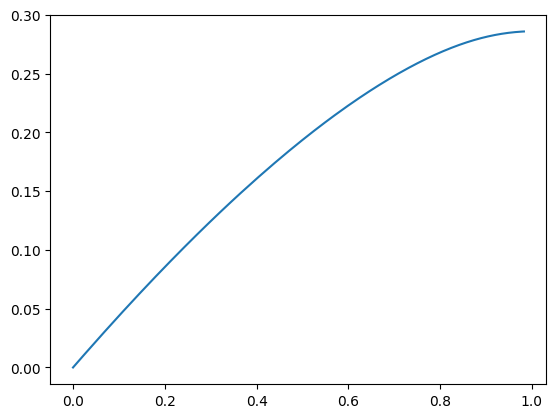

In [11]:
plt.plot(IBbound['I_XR'], IBbound['I_RY'], label='IB Bound')

In [12]:
Xset2 = np.array(list(product(range(2), repeat=7)))
Xset2.shape

(128, 7)

In [13]:
Xset2[:16]

array([[0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 1],
       [0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 1, 1, 0],
       [0, 0, 0, 0, 1, 1, 1],
       [0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 1],
       [0, 0, 0, 1, 0, 1, 0],
       [0, 0, 0, 1, 0, 1, 1],
       [0, 0, 0, 1, 1, 0, 0],
       [0, 0, 0, 1, 1, 0, 1],
       [0, 0, 0, 1, 1, 1, 0],
       [0, 0, 0, 1, 1, 1, 1]])

In [14]:
cuts2 = [0]
p_YgX2 = P_source_g_partsamples_parallel(Xset2, mean_neg, mean_pos, std, cuts2, h=h, P0=P0)
p_YgX2[:16]

array([[0.94753546, 0.05246454],
       [0.7297909 , 0.2702091 ],
       [0.8510224 , 0.1489776 ],
       [0.46070064, 0.53929936],
       [0.90622509, 0.09377491],
       [0.59103013, 0.40896987],
       [0.68392211, 0.31607789],
       [0.24447321, 0.75552679],
       [0.92885604, 0.07114396],
       [0.66129789, 0.33870211],
       [0.76577329, 0.23422671],
       [0.32836965, 0.67163035],
       [0.8176873 , 0.1823127 ],
       [0.40145453, 0.59854547],
       [0.48747091, 0.51252909],
       [0.12452155, 0.87547845]])

In [15]:
p_XgY2 = P_partsamples_g_source_parallel(Xset2, mean_neg, mean_pos, std, cuts2, h=h, window_size=None)
IBbound2 = utils.get_IB_bound(p_XgY2, p_Y, N_threads=22)

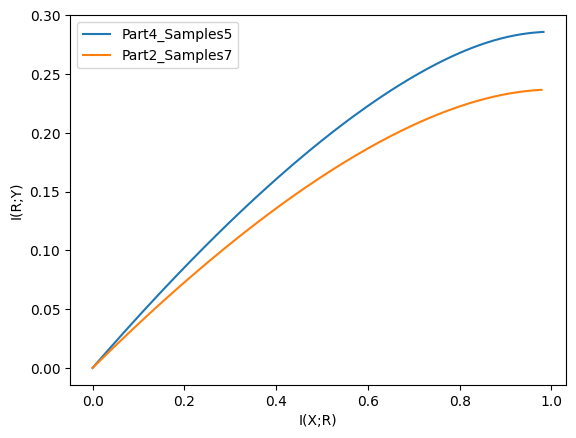

In [16]:
plt.plot(IBbound['I_XR'], IBbound['I_RY'], label='Part4_Samples5')
plt.plot(IBbound2['I_XR'], IBbound2['I_RY'], label='Part2_Samples7')
plt.xlabel('I(X;R)')
plt.ylabel('I(R;Y)')
plt.legend()
plt.show()

In [17]:
Xset3 = np.array(list(product(range(2), repeat=9)))
p_XgY3 = P_partsamples_g_source_parallel(Xset3, mean_neg, mean_pos, std, cuts2, h=h, window_size=None)
IBbound3 = utils.get_IB_bound(p_XgY3, p_Y, N_threads=22)

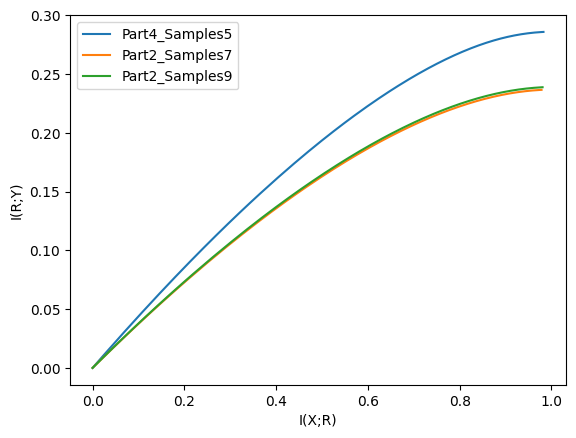

In [18]:
plt.plot(IBbound['I_XR'], IBbound['I_RY'], label='Part4_Samples5')
plt.plot(IBbound2['I_XR'], IBbound2['I_RY'], label='Part2_Samples7')
plt.plot(IBbound3['I_XR'], IBbound3['I_RY'], label='Part2_Samples9')
plt.xlabel('I(X;R)')
plt.ylabel('I(R;Y)')
plt.legend()
plt.show()

In [19]:
participant_id = "DCB"
trials_df, samples_df, block_metadata_df = prepare_subject_data(participant_id)


In [20]:

Xemp = np.stack(trials_df.loc[trials_df["partsamples_arr_5"].notna(),"partsamples_arr_5"].to_numpy())
Yemp = np.stack(trials_df.loc[trials_df["partsamples_arr_5"].notna(),"correct_response_dist"].to_numpy())
Yemp = Yemp - 1  # Convert from 1/2 to 0/1
IBbound_emp = utils.get_IB_bound_emp(Xemp, Xset, Yemp, p_XgY, p_Y,N_threads=22)

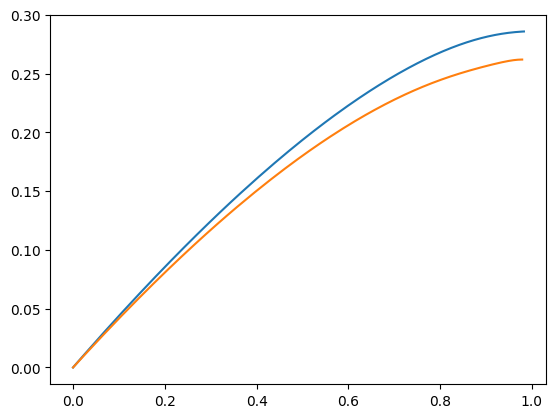

In [21]:
plt.plot(IBbound['I_XR'], IBbound['I_RY'], label='IB Bound')
plt.plot(IBbound_emp['I_XR'], IBbound_emp['I_RY'], label='Empirical IB Bound')

In [22]:
Xemp2 = np.stack(trials_df.loc[trials_df["part2samples_arr_7"].notna(),"part2samples_arr_7"].to_numpy())
Yemp2= np.stack(trials_df.loc[trials_df["part2samples_arr_7"].notna(),"correct_response_dist"].to_numpy())
Yemp2 = Yemp2 - 1  # Convert from 1/2 to 0/1
IBbound2_emp = utils.get_IB_bound_emp(Xemp2, Xset2, Yemp2, p_XgY2, p_Y,N_threads=22)

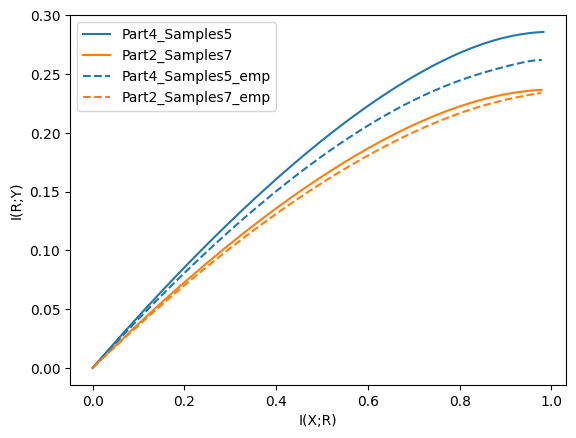

In [23]:
cmap = plt.get_cmap('tab10')
plt.plot(IBbound['I_XR'], IBbound['I_RY'],c=cmap(0), label='Part4_Samples5')
plt.plot(IBbound2['I_XR'], IBbound2['I_RY'],c=cmap(1), label='Part2_Samples7')
plt.plot(IBbound_emp['I_XR'], IBbound_emp['I_RY'],'--',c=cmap(0), label='Part4_Samples5_emp')
plt.plot(IBbound2_emp['I_XR'], IBbound2_emp['I_RY'],'--', c=cmap(1), label='Part2_Samples7_emp')
plt.xlabel('I(X;R)')
plt.ylabel('I(R;Y)')
plt.legend()
plt.show()

In [24]:
trials_df

,block_id,subject_folder,participant_id,session_label,session,block,trial,correct_response_dist,response,accuracy,...,part2samples_arr_5_enc,part2samples_arr_7,post_prob_pos_part2sample7,part2samples_arr_7_enc,part2samples_arr_9,post_prob_pos_part2sample9,part2samples_arr_9_enc,part2samples_arr_11,post_prob_pos_part2sample11,part2samples_arr_11_enc
0,DCB_S1_B1,DCB,DCB,S1,1,1,1,1.0,1.0,1.0,...,10111.0,"[0, 1, 1, 0, 1, 1, 1]",0.906420,110111.0,NaN,NaN,NaN,NaN,NaN,NaN
1,DCB_S1_B1,DCB,DCB,S1,1,1,2,2.0,2.0,1.0,...,101.0,"[1, 0, 0, 0, 1, 0, 1]",0.468497,1000101.0,"[0, 0, 1, 0, 0, 0, 1, 0, 1]",0.419681,1000101.0,"[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1]",0.409822,1.000101e+06
2,DCB_S1_B1,DCB,DCB,S1,1,1,3,2.0,1.0,0.0,...,101.0,"[1, 0, 0, 0, 1, 0, 1]",0.468497,1000101.0,"[0, 1, 1, 0, 0, 0, 1, 0, 1]",0.475404,11000101.0,"[0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]",0.442337,1.100010e+07
3,DCB_S1_B1,DCB,DCB,S1,1,1,4,1.0,1.0,1.0,...,1101.0,"[0, 1, 0, 1, 1, 0, 1]",0.723215,101101.0,"[1, 1, 0, 1, 0, 1, 1, 0, 1]",0.787688,110101101.0,"[1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1]",0.784948,1.011010e+10
4,DCB_S1_B1,DCB,DCB,S1,1,1,5,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2000,DCB_S3_B9,DCB,DCB,S3,3,9,72,1.0,2.0,0.0,...,10.0,"[0, 0, 0, 0, 0, 1, 0]",0.148978,10.0,"[0, 0, 0, 0, 0, 0, 0, 1, 0]",0.145197,10.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]",0.144648,1.000000e+01
2001,DCB_S3_B9,DCB,DCB,S3,3,9,73,2.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002,DCB_S3_B9,DCB,DCB,S3,3,9,74,1.0,1.0,1.0,...,11011.0,"[1, 1, 1, 1, 0, 1, 1]",0.906225,1111011.0,"[1, 0, 1, 1, 1, 1, 0, 1, 1]",0.905406,101111011.0,"[1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1]",0.904805,1.010111e+10
2003,DCB_S3_B9,DCB,DCB,S3,3,9,75,1.0,1.0,1.0,...,11011.0,"[1, 1, 1, 1, 0, 1, 1]",0.906225,1111011.0,"[0, 1, 1, 1, 1, 1, 0, 1, 1]",0.906948,11111011.0,"[1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1]",0.906488,1.001111e+10


In [12]:
participants = discover_participants()
participants_no_2 = [p for p in participants if "2" not in p]
participants_no_2

['DCB',
 'DHB',
 'ECB',
 'EMB',
 'EXF',
 'EXG',
 'GSB',
 'HBC',
 'JTB',
 'KSV',
 'NIF',
 'OMF',
 'PDP',
 'QNV',
 'TFD',
 'TNB',
 'TSJ']

In [13]:
trialsdf_dict = {}
samplesdf_dict = {}
blockmetadatadf_dict = {}
for participant_id in participants_no_2:
    print(f"Processing {participant_id}...")
    trials_df, samples_df, block_metadata_df = prepare_subject_data(participant_id)
    trialsdf_dict[participant_id] = trials_df
    samplesdf_dict[participant_id] = samples_df
    blockmetadatadf_dict[participant_id] = block_metadata_df

Processing DCB...
Processing DHB...
Processing ECB...
Processing EMB...
Processing EXF...
Processing EXG...
Processing GSB...
Processing HBC...
Processing JTB...
Processing KSV...
Processing NIF...
Processing OMF...
Processing PDP...
Processing QNV...
Processing TFD...
Processing TNB...
Processing TSJ...


In [14]:
# number of threads for parallelized analyses
N_threads = 22


### parameters governing analyses ###

# confidence interval of I(R;Y) for bootstrapping analyses
CI = (2.5, 97.5)
boot_iters = 1000 # number of bootstrap iterations

In [11]:
ibdf = pd.DataFrame({
    'subject_ID': [],
    'subject_index': [],
    'Ixr_4_5': [],
    'Ixr_2_7': [],
    'Ixr_2_9': [],
    'Iry_4_5': [],
    'Iry_2_7': [],
    'Iry_2_9': [],
    'Iry_4_5_CI_lower': [],
    'Iry_4_5_CI_upper': [],
    'Iry_2_7_CI_lower': [],
    'Iry_2_7_CI_upper': [],
    'Iry_2_9_CI_lower': [],
    'Iry_2_9_CI_upper': []
})

Xcard_4_5 = 4**5
Xcard_2_7 = 2**7
Xcard_2_9 = 2**9
Rcard = 2
Ycard = 2

sjind = 0
for participant_id in participants_no_2:

    print(participant_id)

    sjdf = pd.DataFrame({
        'subject_ID': [''],
        'subject_index': [np.nan],
        'Ixr_4_5': [np.nan],
        'Ixr_2_7': [np.nan],
        'Ixr_2_9': [np.nan],
        'Iry_4_5': [np.nan],
        'Iry_2_7': [np.nan],
        'Iry_2_9': [np.nan],
        'Iry_4_5_CI_lower': [np.nan],
        'Iry_4_5_CI_upper': [np.nan],
        'Iry_2_7_CI_lower': [np.nan],
        'Iry_2_7_CI_upper': [np.nan],
        'Iry_2_9_CI_lower': [np.nan],
        'Iry_2_9_CI_upper': [np.nan]
    })

    trials_df = trialsdf_dict[participant_id]

    conds_4_5 = (trials_df["partsamples_arr_5"].notna()) & ((trials_df["response"] == 1) | (trials_df["response"] == 2))
    conds_2_7 = (trials_df["part2samples_arr_7"].notna()) & ((trials_df["response"] == 1) | (trials_df["response"] == 2))
    conds_2_9 = (trials_df["part2samples_arr_9"].notna()) & ((trials_df["response"] == 1) | (trials_df["response"] == 2))

    Xemp_4_5 = np.stack(trials_df.loc[conds_4_5,"partsamples_arr_5"].to_numpy())
    Xemp_enc_4_5 = np.sum((10**np.arange(5)) * Xemp_4_5,axis=1)
    Xemp_2_7 = np.stack(trials_df.loc[conds_2_7,"part2samples_arr_7"].to_numpy())
    Xemp_enc_2_7 = np.sum((10**np.arange(7)) * Xemp_2_7,axis=1)
    Xemp_2_9 = np.stack(trials_df.loc[conds_2_9,"part2samples_arr_9"].to_numpy())
    Xemp_enc_2_9 = np.sum((10**np.arange(9)) * Xemp_2_9,axis=1)

    Yemp_4_5 = np.stack(trials_df.loc[conds_4_5,"correct_response_dist"].to_numpy())
    Yemp_4_5 = Yemp_4_5 - 1  # Convert from 1/2 to 0/1
    Yemp_2_7 = np.stack(trials_df.loc[conds_2_7,"correct_response_dist"].to_numpy())
    Yemp_2_7 = Yemp_2_7 - 1  # Convert from 1/2 to 0/1
    Yemp_2_9 = np.stack(trials_df.loc[conds_2_9,"correct_response_dist"].to_numpy())
    Yemp_2_9 = Yemp_2_9 - 1  # Convert from 1/2 to 0/1

    Remp_4_5 = np.stack(trials_df.loc[conds_4_5,"response"].to_numpy())
    Remp_4_5 = Remp_4_5 - 1  # Convert from 1/2 to 0/1
    Remp_2_7 = np.stack(trials_df.loc[conds_2_7,"response"].to_numpy())
    Remp_2_7 = Remp_2_7 - 1  # Convert from 1/2 to 0/1
    Remp_2_9 = np.stack(trials_df.loc[conds_2_9,"response"].to_numpy())
    Remp_2_9 = Remp_2_9 - 1  # Convert from 1/2 to 0/1

    Ixr_4_5 = utils.mutual_inf_nsb(Xemp_enc_4_5, Remp_4_5, [Xcard_4_5, Rcard])
    Ixr_2_7 = utils.mutual_inf_nsb(Xemp_enc_2_7, Remp_2_7, [Xcard_2_7, Rcard])
    Ixr_2_9 = utils.mutual_inf_nsb(Xemp_enc_2_9, Remp_2_9, [Xcard_2_9, Rcard])
    Iry_4_5 = utils.mutual_inf_nsb(Remp_4_5, Yemp_4_5, [Rcard, Ycard])
    Iry_2_7 = utils.mutual_inf_nsb(Remp_2_7, Yemp_2_7, [Rcard, Ycard])
    Iry_2_9 = utils.mutual_inf_nsb(Remp_2_9, Yemp_2_9, [Rcard, Ycard])

    Iry_4_5_CI = utils.get_Iry_CI(Remp_4_5,Yemp_4_5,CI,boot_iters,Rcard=Rcard,Ycard=Ycard,seed=234,N_threads=N_threads)
    Iry_2_7_CI = utils.get_Iry_CI(Remp_2_7,Yemp_2_7,CI,boot_iters,Rcard=Rcard,Ycard=Ycard,seed=234,N_threads=N_threads)
    Iry_2_9_CI = utils.get_Iry_CI(Remp_2_9,Yemp_2_9,CI,boot_iters,Rcard=Rcard,Ycard=Ycard,seed=234,N_threads=N_threads)

    sjdf.loc[0, 'subject_ID'] = participant_id
    sjdf.loc[0, 'subject_index'] = sjind
    sjdf.loc[0, 'Ixr_4_5'] = Ixr_4_5
    sjdf.loc[0, 'Ixr_2_7'] = Ixr_2_7
    sjdf.loc[0, 'Ixr_2_9'] = Ixr_2_9
    sjdf.loc[0, 'Iry_4_5'] = Iry_4_5
    sjdf.loc[0, 'Iry_2_7'] = Iry_2_7
    sjdf.loc[0, 'Iry_2_9'] = Iry_2_9
    sjdf.loc[0, 'Iry_4_5_CI_lower'] = Iry_4_5_CI[0]
    sjdf.loc[0, 'Iry_4_5_CI_upper'] = Iry_4_5_CI[1]
    sjdf.loc[0, 'Iry_2_7_CI_lower'] = Iry_2_7_CI[0]
    sjdf.loc[0, 'Iry_2_7_CI_upper'] = Iry_2_7_CI[1]
    sjdf.loc[0, 'Iry_2_9_CI_lower'] = Iry_2_9_CI[0]
    sjdf.loc[0, 'Iry_2_9_CI_upper'] = Iry_2_9_CI[1]

    ibdf = pd.concat([ibdf, sjdf], ignore_index=True)
    sjind += 1

DCB


NameError: name 'utils' is not defined

In [ ]:
ibdf

,subject_ID,subject_index,Ixr_4_5,Ixr_2_7,Ixr_2_9,Iry_4_5,Iry_2_7,Iry_2_9,Iry_4_5_CI_lower,Iry_4_5_CI_upper,Iry_2_7_CI_lower,Iry_2_7_CI_upper,Iry_2_9_CI_lower,Iry_2_9_CI_upper
0,DCB,0.0,0.420094,0.520903,0.466080,0.248411,0.250227,0.261751,0.218969,0.285354,0.218219,0.287606,0.226720,0.301310
1,DHB,1.0,0.326217,0.384385,0.336840,0.221077,0.218664,0.217528,0.188986,0.259035,0.185106,0.254958,0.181922,0.255217
2,ECB,2.0,0.346902,0.455803,0.412433,0.229759,0.228006,0.222368,0.196817,0.266790,0.195647,0.266736,0.187253,0.259995
3,EMB,3.0,0.400725,0.491869,0.436035,0.246670,0.253155,0.247272,0.211586,0.280945,0.217896,0.290059,0.213938,0.287607
4,EXF,4.0,0.237185,0.362817,0.339137,0.212453,0.217512,0.210796,0.180701,0.246890,0.185454,0.253409,0.179115,0.248403
5,EXG,5.0,0.428391,0.490437,0.432726,0.274900,0.271122,0.270217,0.240956,0.313593,0.234257,0.308899,0.235466,0.310319
6,GSB,6.0,0.161378,0.269061,0.296505,0.174112,0.169777,0.163368,0.145373,0.206925,0.140566,0.202190,0.131933,0.195846
7,HBC,7.0,0.264334,0.389351,0.351164,0.245491,0.240835,0.245175,0.210460,0.282773,0.206094,0.280899,0.208742,0.284004
8,JTB,8.0,0.263598,0.425363,0.363419,0.233086,0.230980,0.231025,0.195839,0.271771,0.194347,0.270403,0.194336,0.275253
9,KSV,9.0,0.184965,0.342752,0.324519,0.165453,0.164801,0.171871,0.138154,0.200421,0.136254,0.195655,0.138783,0.207733


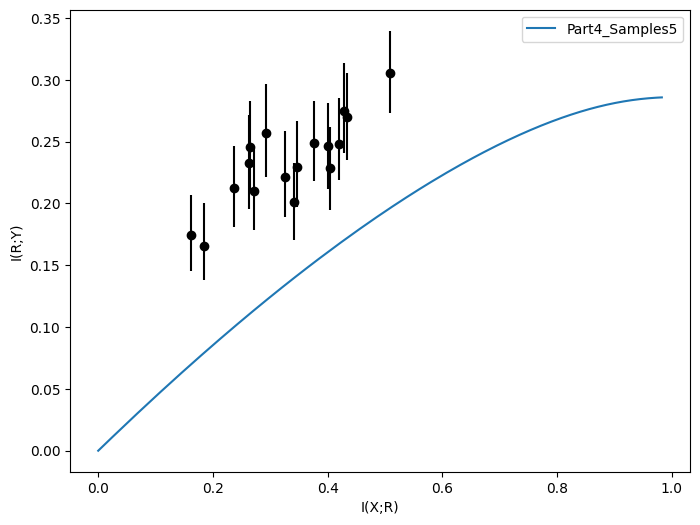

In [30]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(IBbound['I_XR'], IBbound['I_RY'], label='Part4_Samples5')
# ax.scatter(ibdf['Ixr_4_5'], ibdf['Iry_4_5'])
ax.errorbar(ibdf['Ixr_4_5'], ibdf['Iry_4_5'], yerr=[ibdf['Iry_4_5']-ibdf['Iry_4_5_CI_lower'], ibdf['Iry_4_5_CI_upper']-ibdf['Iry_4_5']], fmt='o',c='k')
ax.set_xlabel('I(X;R)')
ax.set_ylabel('I(R;Y)')
ax.legend()
plt.show()

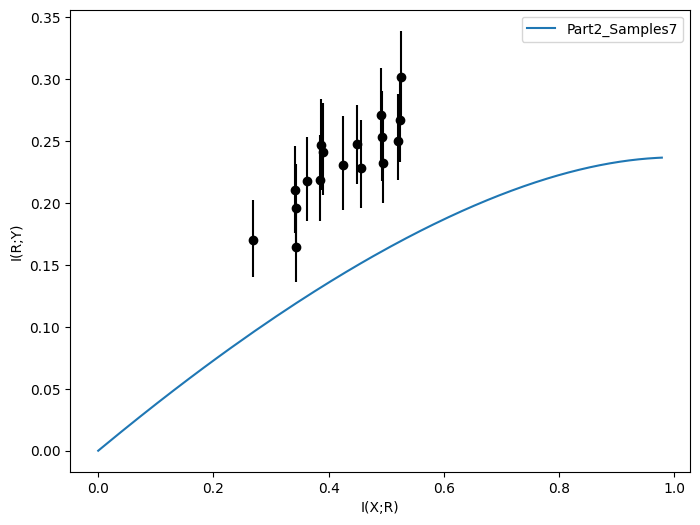

In [31]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(IBbound2['I_XR'], IBbound2['I_RY'], label='Part2_Samples7')
# ax.scatter(ibdf['Ixr_4_5'], ibdf['Iry_4_5'])
ax.errorbar(ibdf['Ixr_2_7'], ibdf['Iry_2_7'], yerr=[ibdf['Iry_2_7']-ibdf['Iry_2_7_CI_lower'], ibdf['Iry_2_7_CI_upper']-ibdf['Iry_2_7']], fmt='o',c='k')
ax.set_xlabel('I(X;R)')
ax.set_ylabel('I(R;Y)')
ax.legend()
plt.show()

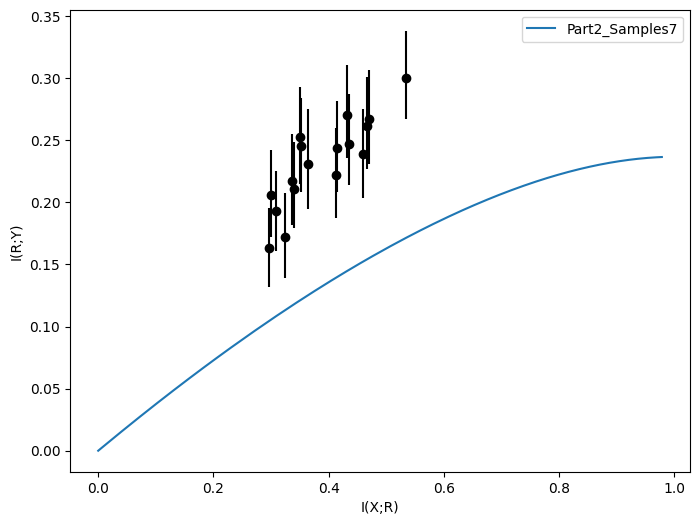

In [32]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(IBbound2['I_XR'], IBbound2['I_RY'], label='Part2_Samples7')
# ax.scatter(ibdf['Ixr_4_5'], ibdf['Iry_4_5'])
ax.errorbar(ibdf['Ixr_2_9'], ibdf['Iry_2_9'], yerr=[ibdf['Iry_2_9']-ibdf['Iry_2_9_CI_lower'], ibdf['Iry_2_9_CI_upper']-ibdf['Iry_2_9']], fmt='o',c='k')
ax.set_xlabel('I(X;R)')
ax.set_ylabel('I(R;Y)')
ax.legend()
plt.show()

In [15]:
import multiprocessing as mp

def generate_trials(n_trials, mirror_trials=False, balanced_starts=False, seed=None):
    """Generate trials from a two-state switching Gaussian process.

    Parameters
    ----------
    n_trials : int
        Number of independent trials to generate.
    balanced_starts : bool, default=False
        If True, exactly half of the trials start in each source
        distribution. This requires an even ``n_trials``.
    seed : int or None, default=None
        Seed for NumPy's random-number generator. Use an integer for
        reproducible simulations.

    Returns
    -------
    X : ndarray of int, shape (n_trials, 12)
        Clipped and rounded observations for each trial.
    Y : ndarray of int, shape (n_trials,)
        Identity of the source for the final draw: 0 denotes the Gaussian
        with mean -17 and 1 denotes the Gaussian with mean 17.
    """
    if isinstance(n_trials, (bool, np.bool_)) or not isinstance(n_trials, (int, np.integer)):
        raise TypeError("n_trials must be an integer")
    if n_trials < 0:
        raise ValueError("n_trials must be non-negative")
    if (balanced_starts or mirror_trials) and n_trials % 2:
        raise ValueError("balanced_starts=True or mirror_trials=True requires an even n_trials")

    rng = np.random.default_rng(seed)
    n_draws = 12
    source_means = np.array([-17.0, 17.0])

    if mirror_trials:
        n_trials_ = n_trials // 2
    else:
        n_trials_ = n_trials

    if balanced_starts:
        starts = np.repeat([0, 1], n_trials_ // 2)
        rng.shuffle(starts)
    else:
        starts = rng.integers(0, 2, size=n_trials_)

    print(starts.shape)
    print(n_trials_)
    # switches[:, j] indicates whether the source changes between draws
    # j and j + 1. Cumulative parity therefore gives the source at each draw.
    switches = rng.random((n_trials_, n_draws - 1)) < 0.08
    source_paths = np.column_stack(
        [starts, starts[:, None] ^ np.logical_xor.accumulate(switches, axis=1)]
    ).astype(int)

    raw_draws = rng.normal(loc=source_means[source_paths], scale=29.0)
    X = np.rint(np.clip(raw_draws, -90, 90)).astype(int)
    Y = source_paths[:, -1].copy()
    if mirror_trials:
        X = np.concatenate([X, -X], axis=0)
        Y = np.concatenate([Y, 1-Y], axis=0)
    return X, Y

def IB_fn_emp(beta,p_RgX_emp,Yemp):
    Ixr = utils.compute_I_XR_emp(p_RgX_emp)
    Iry = utils.compute_I_RY_emp(p_RgX_emp,Yemp)
    return Ixr - beta*Iry

def mc_IB(beta,Ysample,p_YgX_sample,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=209,return_dict=True):

    rng = np.random.default_rng(seed)

    N_y = p_YgX_sample.shape[1]
    N_x = p_YgX_sample.shape[0]

    Yoh = np.eye(N_y)[Ysample.astype(int)]

    IB_fxn_vals = []
    p_RgXs = []
    p_Rs = []
    p_YgRs = []

    for ii in range(N_inits):
        p_R = (np.ones(N_y) / N_y).reshape(1,-1)
        if init == 'random':
            p_RX = np.exp(rng.random((N_x,N_y)))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)
        elif init == 'softmax':
            if betastar is None:
                betastar = beta
            p_RgX = np.exp(betastar*p_YgX_sample) / np.sum(np.exp(betastar*p_YgX_sample),axis=1,keepdims=True)
        p_RX = p_RgX * (1/N_x)
        p_XgR = p_RX / p_R
        p_YgR = Yoh.T @ p_XgR
        IB_fxn = IB_fn_emp(beta,p_RgX,Ysample)
        delta = 1
        iters = 0
        while (delta > 1e-15) or (iters < 100):
            # store last copy
            IB_fxn_last = IB_fxn

            # update p(r|x)
            p_RX = p_R * np.exp(beta*(p_YgX_sample @ np.log(p_YgR))) # we can simplify the original update rule (below) to this
            # p_RX = p_R * np.exp(-beta*np.sum(p_YgX[:,:,np.newaxis] * (np.log(p_YgX[:,:,np.newaxis]) - np.log(p_YgR[np.newaxis,:,:])),axis=1))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)


            # update p(r)
            p_R = p_RgX.sum(axis=0,keepdims=True) / N_x

            #update p(y|r)
            p_RX = p_RgX * (1/N_x)
            p_XgR = p_RX / p_R
            p_YgR = Yoh.T @ p_XgR

            IB_fxn = IB_fn_emp(beta,p_RgX,Ysample)

            delta = np.abs(IB_fxn - IB_fxn_last)
            iters += 1
            if iters == iterlimit:
                break
        IB_fxn_vals.append(IB_fxn.copy())
        p_RgXs.append(p_RgX.copy())
        p_Rs.append(p_R.copy())
        p_YgRs.append(p_YgR.copy())

    min_ind = np.argmin(np.array(IB_fxn_vals))
    p_RgX = p_RgXs[min_ind]
    p_R = p_Rs[min_ind]
    p_YgR = p_YgRs[min_ind]

    H_R = -np.sum(p_R * np.log2(p_R))
    I_XR = utils.compute_I_XR_emp(p_RgX)
    I_RY = utils.compute_I_RY_emp(p_RgX,Ysample)

    if return_dict:
        out = {
            'I_XR': I_XR,
            'I_RY': I_RY,
            'beta': beta,
            'H_R': H_R,
            'p_YgR': p_YgR,
            'p_R': p_R,
            'betastar': betastar
        }
        return out
    else:
        return [I_XR, I_RY, beta, H_R, p_YgR, p_R, betastar]

def mc_IB_mp(args):
    return mc_IB(*args)

# mc_IB(beta,Ysample,p_YgX_sample,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=209,return_dict=True)
def get_mc_IB_bound(Ysample,p_YgX_sample,N_b=100,max_b=50,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=1, seed=209, sort_by_beta=True):

    if beta_array is None:
        beta_array = np.linspace(max_b/N_b,max_b,N_b)

    with mp.Pool(processes=N_threads) as pool:
        results = [pool.apply_async(mc_IB_mp, args=((beta_array[ib], Ysample, p_YgX_sample, iterlimit, init, N_inits, betastar_array[ib] if betastar_array is not None else None, seed, False),)) for ib in range(N_b)]
        results = [res.get() for res in results]
    I_XR = [res[0] for res in results]
    I_RY = [res[1] for res in results]
    betas = [res[2] for res in results]
    H_Rs = [res[3] for res in results]
    p_YgRs = [res[4] for res in results]
    p_Rs = [res[5] for res in results]

    if sort_by_beta:
        sort_indices = np.argsort(betas)
    else:
        sort_indices = np.arange(len(betas))
    out = {
        'I_XR': np.array(I_XR)[sort_indices],
        'I_RY': np.array(I_RY)[sort_indices],
        'beta': np.array(betas)[sort_indices],
        'H_R': np.array(H_Rs)[sort_indices],
        'p_YgR': np.array(p_YgRs)[sort_indices],
        'p_R': np.array(p_Rs)[sort_indices]
    }
    return out

In [16]:
def P_source_g_samples(samples_arr,mean_neg,mean_pos,std,h,P0,window_size=None):
    P_sample_g_neg = np.diff(np.concatenate([np.array([0]),norm(loc=mean_neg,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
    P_sample_g_pos = np.diff(np.concatenate([np.array([0]),norm(loc=mean_pos,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
    # P_sample_g_neg = norm(loc=mean_neg, scale=std)
    # P_sample_g_pos = norm(loc=mean_pos, scale=std)
    Lneg = P_sample_g_neg[samples_arr + 90]
    Lpos = P_sample_g_pos[samples_arr + 90]
    L = np.concatenate((Lneg[:,np.newaxis,:],Lpos[:,np.newaxis,:]),axis=1)
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    P = P0.copy()
    if window_size is not None:
        L = L[:,:,-window_size:]
    for ii in range(L.shape[2]):
        P = L[:,:,ii][:,:,np.newaxis] * (H @ P)
    P = P / P.sum(axis=1, keepdims=True)
    return P.squeeze()

In [17]:
Xsample,Ysample = generate_trials(100000, mirror_trials=True, balanced_starts=True, seed=234)
p_YgX_sample = P_source_g_samples(Xsample, mean_neg, mean_pos, std, h, P0)

(50000,)
50000


(array([1.56850126, 2.41547186, 2.49976752, 2.42851762, 2.15455675,
        2.06323646, 1.89966275, 1.71200457, 1.65580747, 1.52434639,
        1.44406482, 1.33969877, 1.19418842, 1.20623065, 1.11892444,
        1.08380125, 1.02760415, 0.94631906, 0.90818531, 0.90517475,
        0.86804452, 0.84697061, 0.7957911 , 0.77772775, 0.76769255,
        0.74059752, 0.72253417, 0.6783793 , 0.67235818, 0.67938282,
        0.69142506, 0.63422444, 0.59709421, 0.64927723, 0.65028075,
        0.54190063, 0.57702381, 0.62820332, 0.57602029, 0.55896046,
        0.54190063, 0.57501678, 0.60512237, 0.5559499 , 0.53587951,
        0.55193582, 0.49874928, 0.53688303, 0.50276336, 0.52183023,
        0.52183023, 0.50276336, 0.53688303, 0.49874928, 0.55193582,
        0.53587951, 0.5559499 , 0.60512237, 0.57501678, 0.54190063,
        0.55896046, 0.57602029, 0.62820332, 0.57702381, 0.54190063,
        0.65028075, 0.64927723, 0.59709421, 0.63422444, 0.69142506,
        0.67938282, 0.67235818, 0.6783793 , 0.72

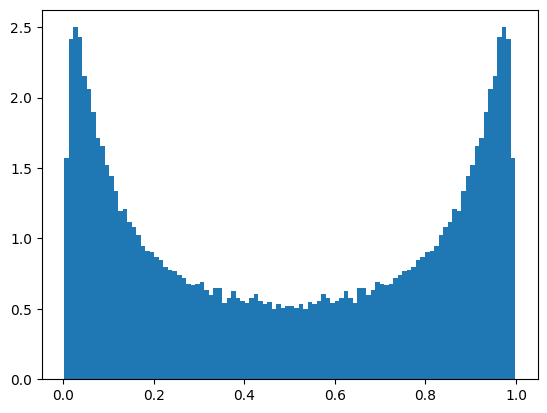

In [18]:
plt.hist(p_YgX_sample[:,1], bins=100, density=True)

In [19]:
np.unique(Ysample, return_counts=True)

(array([0, 1]), array([50000, 50000]))

In [24]:
IB_bound_mc = get_mc_IB_bound(Ysample,p_YgX_sample,N_b=100,max_b=20,iterlimit=100000,init='random',N_inits=3,betastar_array=None,N_threads=22,seed=234,sort_by_beta=True)

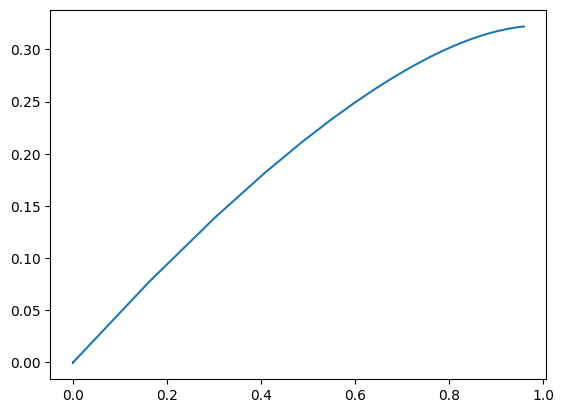

In [25]:
plt.plot(IB_bound_mc['I_XR'], IB_bound_mc['I_RY'], label='MC IB Bound')

In [28]:
from choice_information import (
    default_model_library,
    estimate_choice_information,
    bootstrap_choice_information,
    plot_choice_information_diagnostics,
    plot_bootstrap_choice_information,
)

ibdf = pd.DataFrame({
    'subject_ID': [],
    'subject_index': [],
    'Ixr': [],
    'Iry': [],
    'Iry_CI_lower': [],
    'Iry_CI_upper': []
})

Rcard = 2
Ycard = 2

sjind = 0
for participant_id in participants_no_2:

    print(participant_id)

    sjdf = pd.DataFrame({
        'subject_ID': [''],
        'subject_index': [np.nan],
        'Ixr': [np.nan],
        'Iry': [np.nan],
        'Iry_CI_lower': [np.nan],
        'Iry_CI_upper': [np.nan]
    })

    trials_df = trialsdf_dict[participant_id]

    # trial_df["n_presented_samples"]
    conds = (trials_df['n_presented_samples']==12) & ((trials_df["response"] == 1) | (trials_df["response"] == 2))
    Xemp = np.stack(trials_df.loc[conds,"samples_arr"].to_numpy())
    Yemp = np.stack(trials_df.loc[conds,"correct_response_dist"].to_numpy())
    Yemp = Yemp - 1  # Convert from 1/2 to 0/1
    Remp = np.stack(trials_df.loc[conds,"response"].to_numpy())
    Remp = Remp - 1  # Convert from 1/2 to 0/1

    result = estimate_choice_information(
        Xemp,
        Remp,
        fold_mode="random",
        n_splits=5,
        inner_n_splits=3,
        random_state=2026,
    )

    Ixr = result["mi_lower_bound_bits"]
    Iry = utils.mutual_inf_nsb(Remp, Yemp, [Rcard, Ycard])

    Iry_CI = utils.get_Iry_CI(Remp,Yemp,CI,boot_iters,Rcard=Rcard,Ycard=Ycard,seed=234,N_threads=N_threads)

    sjdf.loc[0, 'subject_ID'] = participant_id
    sjdf.loc[0, 'subject_index'] = sjind
    sjdf.loc[0, 'Ixr'] = Ixr
    sjdf.loc[0, 'Iry'] = Iry
    sjdf.loc[0, 'Iry_CI_lower'] = Iry_CI[0]
    sjdf.loc[0, 'Iry_CI_upper'] = Iry_CI[1]

    ibdf = pd.concat([ibdf, sjdf], ignore_index=True)
    sjind += 1

DCB
DHB
ECB
EMB
EXF
EXG
GSB
HBC
JTB
KSV
NIF
OMF
PDP
QNV
TFD
TNB
TSJ


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


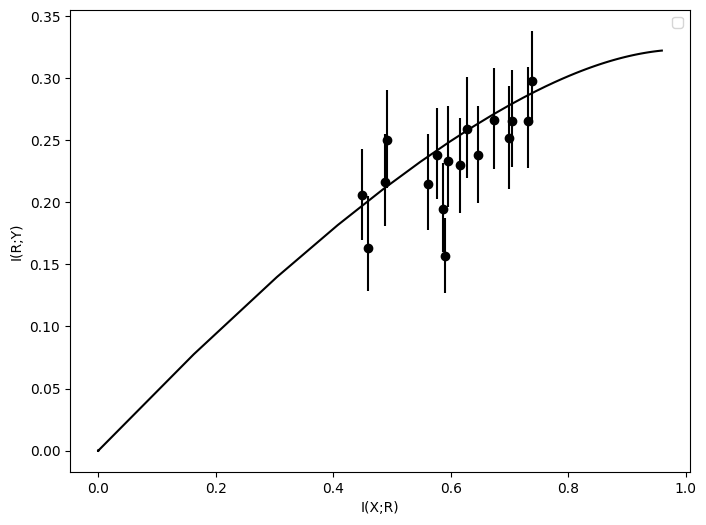

In [29]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(IB_bound_mc['I_XR'], IB_bound_mc['I_RY'], 'k')
# ax.scatter(ibdf['Ixr_4_5'], ibdf['Iry_4_5'])
ax.errorbar(ibdf['Ixr'], ibdf['Iry'], yerr=[ibdf['Iry']-ibdf['Iry_CI_lower'], ibdf['Iry_CI_upper']-ibdf['Iry']], fmt='o',c='k')
ax.set_xlabel('I(X;R)')
ax.set_ylabel('I(R;Y)')
ax.legend()
plt.show()

In [ ]:
def alt_IB(beta,N_r,Ysample,p_YgX_sample,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=209,return_dict=True):

    rng = np.random.default_rng(seed)

    N_y = p_YgX_sample.shape[1]
    N_x = p_YgX_sample.shape[0]

    Yoh = np.eye(N_y)[Ysample.astype(int)]

    IB_fxn_vals = []
    p_RgXs = []
    p_Rs = []
    p_YgRs = []

    for ii in range(N_inits):
        if init == 'random':
            RgX_sample = rng.normal(size=(N_x,N_r))
        p_YgR = p_YgX_sample.T @ 

In [ ]:
def alt_alt_IB(beta,N_r,p_XgY,p_Y,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=209,return_dict=True):

    rng = np.random.default_rng(seed)

    N_y = p_XgY.shape[1]
    N_x = p_XgY.shape[0]

    if p_Y is None:
        p_Y = np.array([1/N_y]*N_y)

    p_XY = p_XgY * p_Y
    p_X = np.sum(p_XY, axis=1, keepdims=True)
    p_YgX = p_XY / p_X

    IB_fxn_vals = []
    p_RgXs = []
    p_Rs = []
    p_YgRs = []
    for ii in range(N_inits):
        if init == 'random':
            RgX_sample = rng.normal(size=(N_x,N_r))
        p_R = 1 / N_r
        p_YgR = 

In [ ]:
def solve_IB(beta, p_XgY, p_Y, iterlimit=100000, init='random', N_inits=3, betastar=None, base_seed=209, ib_num=0, return_dict=True):

    rng = np.random.default_rng(base_seed + ib_num)

    N_y = p_XgY.shape[1]
    N_x = p_XgY.shape[0]

    if p_Y is None:
        p_Y = np.array([1/N_y]*N_y)

    p_XY = p_XgY * p_Y
    p_X = np.sum(p_XY, axis=1, keepdims=True)
    p_YgX = p_XY / p_X

    IB_fxn_vals = []
    p_RgXs = []
    p_Rs = []
    p_YgRs = []
    for ii in range(N_inits):

        p_R = (np.ones(N_y) / N_y).reshape(1,-1)
        if init == 'random':
            p_RX = np.exp(rng.random((N_x,N_y)))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)
        elif init == 'softmax':
            if betastar is None:
                betastar = beta
            p_RgX = np.exp(betastar*p_YgX) / np.sum(np.exp(betastar*p_YgX),axis=1,keepdims=True)
        p_XgR = (p_RgX * p_X) / p_R
        p_YgR =  p_YgX.T @ p_XgR
        IB_fxn = compute_IB_fn(beta,p_RgX,p_XgY,p_Y)
        delta = 1
        iters = 0
        while (delta > 1e-15) or (iters < 100):
            # store last copy
            IB_fxn_last = IB_fxn

            # update p(r|x)
            p_RX = p_R * np.exp(beta*(p_YgX @ np.log(p_YgR))) # we can simplify the original update rule (below) to this
            # p_RX = p_R * np.exp(-beta*np.sum(p_YgX[:,:,np.newaxis] * (np.log(p_YgX[:,:,np.newaxis]) - np.log(p_YgR[np.newaxis,:,:])),axis=1))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)

            # update p(r)
            p_R = p_X.T @ p_RgX

            #update p(y|r)
            p_XgR = (p_RgX * p_X) / p_R
            p_YgR =  p_YgX.T @ p_XgR

            IB_fxn = compute_IB_fn(beta,p_RgX,p_XgY,p_Y)

            delta = np.abs(IB_fxn - IB_fxn_last)
            iters += 1
            if iters == iterlimit:
                break
        IB_fxn_vals.append(IB_fxn.copy())
        p_RgXs.append(p_RgX.copy())
        p_Rs.append(p_R.copy())
        p_YgRs.append(p_YgR.copy())

    min_ind = np.argmin(np.array(IB_fxn_vals))
    p_RgX = p_RgXs[min_ind]
    p_R = p_Rs[min_ind]
    p_YgR = p_YgRs[min_ind]
    # p_RY = p_YgR * p_R

    H_R = -np.sum(p_R * np.log2(p_R))
    I_XR = compute_I_XR(p_RgX,p_XgY,p_Y)
    I_RY = compute_I_RY(p_RgX,p_XgY,p_Y)

    if return_dict:
        out = {
            'I_XR': I_XR,
            'I_RY': I_RY,
            'beta': beta,
            'H_R': H_R,
            'p_RgX': p_RgX,
            'p_YgR': p_YgR,
            'p_R': p_R,
            'betastar': betastar
        }
        return out
    else:
        return [I_XR, I_RY, beta, H_R, p_RgX, p_YgR, p_R, betastar]

In [ ]:
def mc_IB(beta,Ysample,p_YgX_sample,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=209,return_dict=True):

    rng = np.random.default_rng(seed)

    N_y = p_YgX_sample.shape[1]
    N_x = p_YgX_sample.shape[0]

    Yoh = np.eye(N_y)[Ysample.astype(int)]

    IB_fxn_vals = []
    p_RgXs = []
    p_Rs = []
    p_YgRs = []

    for ii in range(N_inits):
        p_R = (np.ones(N_y) / N_y).reshape(1,-1)
        if init == 'random':
            p_RX = np.exp(rng.random((N_x,N_y)))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)
        elif init == 'softmax':
            if betastar is None:
                betastar = beta
            p_RgX = np.exp(betastar*p_YgX_sample) / np.sum(np.exp(betastar*p_YgX_sample),axis=1,keepdims=True)
        p_RX = p_RgX * (1/N_x)
        p_XgR = p_RX / p_R
        p_YgR = Yoh.T @ p_XgR
        IB_fxn = IB_fn_emp(beta,p_RgX,Ysample)
        delta = 1
        iters = 0
        while (delta > 1e-15) or (iters < 100):
            # store last copy
            IB_fxn_last = IB_fxn

            # update p(r|x)
            p_RX = p_R * np.exp(beta*(p_YgX_sample @ np.log(p_YgR))) # we can simplify the original update rule (below) to this
            # p_RX = p_R * np.exp(-beta*np.sum(p_YgX[:,:,np.newaxis] * (np.log(p_YgX[:,:,np.newaxis]) - np.log(p_YgR[np.newaxis,:,:])),axis=1))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)


            # update p(r)
            p_R = p_RgX.sum(axis=0,keepdims=True) / N_x

            #update p(y|r)
            p_RX = p_RgX * (1/N_x)
            p_XgR = p_RX / p_R
            p_YgR = Yoh.T @ p_XgR

            IB_fxn = IB_fn_emp(beta,p_RgX,Ysample)

            delta = np.abs(IB_fxn - IB_fxn_last)
            iters += 1
            if iters == iterlimit:
                break
        IB_fxn_vals.append(IB_fxn.copy())
        p_RgXs.append(p_RgX.copy())
        p_Rs.append(p_R.copy())
        p_YgRs.append(p_YgR.copy())

    min_ind = np.argmin(np.array(IB_fxn_vals))
    p_RgX = p_RgXs[min_ind]
    p_R = p_Rs[min_ind]
    p_YgR = p_YgRs[min_ind]

    H_R = -np.sum(p_R * np.log2(p_R))
    I_XR = utils.compute_I_XR_emp(p_RgX)
    I_RY = utils.compute_I_RY_emp(p_RgX,Ysample)

    if return_dict:
        out = {
            'I_XR': I_XR,
            'I_RY': I_RY,
            'beta': beta,
            'H_R': H_R,
            'p_YgR': p_YgR,
            'p_R': p_R,
            'betastar': betastar
        }
        return out
    else:
        return [I_XR, I_RY, beta, H_R, p_YgR, p_R, betastar]

In [30]:
import pickle

with open("IB_bound_mc.pkl", "wb") as f:
    pickle.dump(IB_bound_mc, f)

In [65]:
out = mc_IB(beta=10,Ysample=Ysample,p_YgX_sample=p_YgX_sample,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=None,return_dict=True)

KeyboardInterrupt: 

In [ ]:
out

{'I_XR': 0.7231887637419919,
 'I_RY': 0.28407812812511557,
 'beta': 4,
 'H_R': 1.0,
 'p_YgR': array([[0.80298298, 0.19701702],
        [0.19701702, 0.80298298]]),
 'p_R': array([[0.5, 0.5]]),
 'betastar': None}

In [19]:
from scipy.special import softmax

p_RgX_test = softmax(3*p_YgX_sample,axis=1)
p_RgX_test

array([[0.40170859, 0.59829141],
       [0.33176093, 0.66823907],
       [0.13803687, 0.86196313],
       ...,
       [0.94859174, 0.05140826],
       [0.23951765, 0.76048235],
       [0.83933291, 0.16066709]])

In [20]:
utils.compute_I_XR_emp(p_RgX_test)

0.44633493976985295

In [21]:
utils.compute_I_RY_emp(p_RgX_test,Ysample)

0.19707982053752823

In [23]:
IB_fn_emp(1,p_RgX_test,Ysample)

0.2492551192323247

In [24]:
rng = np.random.default_rng(234)

N_y = Ysample.shape[0]
N_x = p_YgX_sample.shape[0]
p_R = (np.ones(N_y) / N_y).reshape(1,-1)
p_RX = np.exp(rng.random((N_x,N_y)))
p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)

In [26]:
p_RgX.shape

(10000, 10000)

In [ ]:
def IB_fn_emp(beta,p_RgX_emp,Yemp):
    Ixr = utils.compute_I_XR_emp(p_RgX_emp)
    Iry = utils.compute_I_RY_emp(p_RgX_emp,Yemp)
    return Ixr - beta*Iry

def mc_IB(beta,Ysample,p_YgX_sample,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=209,return_dict=True):

    rng = np.random.default_rng(seed)

    N_y = Ysample.shape[0]
    N_x = p_YgX_sample.shape[0]

    Yoh = np.eye(N_y)[Ysample.astype(int)]

    IB_fxn_vals = []
    p_RgXs = []
    p_Rs = []
    p_YgRs = []

    for ii in range(N_inits):
        p_R = (np.ones(N_y) / N_y).reshape(1,-1)
        if init == 'random':
            p_RX = np.exp(rng.random((N_x,N_y)))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)
        elif init == 'softmax':
            if betastar is None:
                betastar = beta
            p_RgX = np.exp(betastar*p_YgX_sample) / np.sum(np.exp(betastar*p_YgX_sample),axis=1,keepdims=True)
        p_RX = p_RgX * (1/N_x)
        p_XgR = p_RX / p_R
        p_YgR = Yoh.T @ p_XgR
        IB_fxn = IB_fn_emp(beta,p_RgX,Ysample)
        delta = 1
        iters = 0
        print(p_YgX_sample.shape)
        print(p_YgR.shape)
        while (delta > 1e-15) or (iters < 100):
            # store last copy
            IB_fxn_last = IB_fxn

            # update p(r|x)
            p_RX = p_R * np.exp(beta*(p_YgX_sample @ np.log(p_YgR))) # we can simplify the original update rule (below) to this
            # p_RX = p_R * np.exp(-beta*np.sum(p_YgX[:,:,np.newaxis] * (np.log(p_YgX[:,:,np.newaxis]) - np.log(p_YgR[np.newaxis,:,:])),axis=1))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)


            # update p(r)
            p_R = p_RgX.sum(axis=0,keepdims=True) / N_x

            #update p(y|r)
            p_RX = p_RgX * (1/N_x)
            p_XgR = p_RX / p_R
            p_YgR = Yoh.T @ p_XgR

            IB_fxn = IB_fn_emp(beta,p_RgX,Ysample)

            delta = np.abs(IB_fxn - IB_fxn_last)
            iters += 1
            if iters == iterlimit:
                break
        IB_fxn_vals.append(IB_fxn.copy())
        p_RgXs.append(p_RgX.copy())
        p_Rs.append(p_R.copy())
        p_YgRs.append(p_YgR.copy())

    min_ind = np.argmin(np.array(IB_fxn_vals))
    p_RgX = p_RgXs[min_ind]
    p_R = p_Rs[min_ind]
    p_YgR = p_YgRs[min_ind]

    H_R = -np.sum(p_R * np.log2(p_R))
    I_XR = utils.compute_I_XR_emp(p_RgX)
    I_RY = utils.compute_I_RY_emp(p_RgX,Ysample)

    if return_dict:
        out = {
            'I_XR': I_XR,
            'I_RY': I_RY,
            'beta': beta,
            'H_R': H_R,
            'p_YgR': p_YgR,
            'p_R': p_R,
            'betastar': betastar
        }
        return out
    else:
        return [I_XR, I_RY, beta, H_R, p_YgR, p_R, betastar]

def mc_IB_mp(args):
    return mc_IB(*args)

# mc_IB(beta,Ysample,p_YgX_sample,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=209,return_dict=True)
def get_mc_IB_bound(Ysample,p_YgX_sample,N_b=100,max_b=50,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=1, seed=209, sort_by_beta=True):

    if beta_array is None:
        beta_array = np.linspace(max_b/N_b,max_b,N_b)

    with mp.Pool(processes=N_threads) as pool:
        results = [pool.apply_async(mc_IB_mp, args=((beta_array[ib], Ysample, p_YgX_sample, iterlimit, init, N_inits, betastar_array[ib] if betastar_array is not None else None, seed),)) for ib in range(N_b)]
        results = [res.get() for res in results]
    I_XR = [res[0] for res in results]
    I_RY = [res[1] for res in results]
    betas = [res[2] for res in results]
    H_Rs = [res[3] for res in results]
    p_YgRs = [res[4] for res in results]
    p_Rs = [res[5] for res in results]

    if sort_by_beta:
        sort_indices = np.argsort(betas)
    else:
        sort_indices = np.arange(len(betas))
    out = {
        'I_XR': np.array(I_XR)[sort_indices],
        'I_RY': np.array(I_RY)[sort_indices],
        'beta': np.array(betas)[sort_indices],
        'H_R': np.array(H_Rs)[sort_indices],
        'p_YgR': np.array(p_YgRs)[sort_indices],
        'p_R': np.array(p_Rs)[sort_indices]
    }
    return out

In [40]:
Xsample.shape

(1000000, 12)

In [41]:
Ysample.shape

(1000000,)

In [64]:
IBbound_dict = {}
for participant_id in participants_no_2:
    print(participant_id)
    trials_df = trialsdf_dict[participant_id]
    conds = (trials_df["partsamples_arr_5"].notna()) & ((trials_df["response"] == 1) | (trials_df["response"] == 2))
    Xemp = np.stack(trials_df.loc[conds,"partsamples_arr_5"].to_numpy())
    Yemp = np.stack(trials_df.loc[conds,"correct_response_dist"].to_numpy())
    Yemp = Yemp - 1  # Convert from 1/2 to 0/1
    IBbound_dict[participant_id] = utils.get_IB_bound_emp(Xemp, Xset, Yemp, p_XgY, p_Y,N_threads=22)

DCB
DHB
ECB
EMB
EXF
EXG
GSB
HBC
JTB
KSV
NIF
OMF
PDP
QNV
TFD
TNB
TSJ


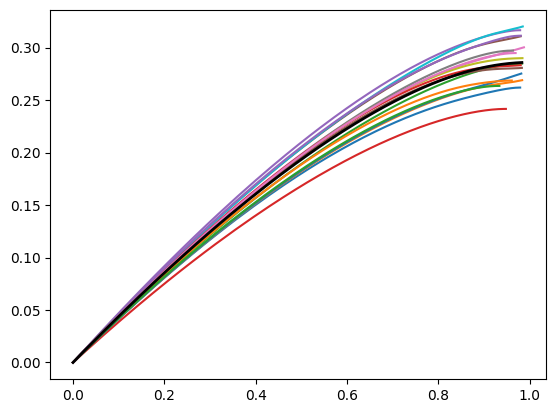

In [66]:
for bound in IBbound_dict.values():
    plt.plot(bound['I_XR'], bound['I_RY'])
plt.plot(IBbound['I_XR'], IBbound['I_RY'],'k',linewidth=2)

In [51]:
trials_df

,block_id,subject_folder,participant_id,session_label,session,block,trial,correct_response_dist,response,accuracy,...,partsamples_arr_5,post_prob_pos_partsample5,partsamples_arr_5_enc,part2samples_arr,part2samples_arr_5,post_prob_pos_part2sample5,part2samples_arr_5_enc,part2samples_arr_7,post_prob_pos_part2sample7,part2samples_arr_7_enc
0,TSJ_S1_B1,TSJ,TSJ,S1,1,1,1,1.0,1.0,1.0,...,NaN,NaN,NaN,"[1, 1]",NaN,NaN,NaN,NaN,NaN,NaN
1,TSJ_S1_B1,TSJ,TSJ,S1,1,1,2,1.0,1.0,1.0,...,"[2, 2, 3, 1, 2]",0.822476,22312.0,"[1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1]","[1, 1, 1, 0, 1]",0.825933,11101.0,"[1, 1, 1, 1, 1, 0, 1]",0.851022,1111101.0
2,TSJ_S1_B1,TSJ,TSJ,S1,1,1,3,2.0,2.0,1.0,...,"[2, 0, 1, 0, 2]",0.186544,20102.0,"[1, 0, 0, 0, 1]","[1, 0, 0, 0, 1]",0.385205,10001.0,NaN,NaN,NaN
3,TSJ_S1_B1,TSJ,TSJ,S1,1,1,4,2.0,1.0,0.0,...,"[1, 2, 3, 1, 1]",0.555567,12311.0,"[1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0]","[0, 1, 1, 0, 0]",0.268960,1100.0,"[1, 0, 0, 1, 1, 0, 0]",0.257319,1001100.0
4,TSJ_S1_B1,TSJ,TSJ,S1,1,1,5,1.0,1.0,1.0,...,"[3, 3, 3, 3, 2]",0.939702,33332.0,"[0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1]","[1, 1, 1, 1, 1]",0.942462,11111.0,"[1, 0, 1, 1, 1, 1, 1]",0.941465,1011111.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2051,TSJ_S3_B9,TSJ,TSJ,S3,3,9,72,1.0,2.0,0.0,...,"[3, 2, 1, 3, 1]",0.780882,32131.0,"[0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0]","[1, 1, 0, 1, 0]",0.520733,11010.0,"[0, 1, 1, 1, 0, 1, 0]",0.531503,111010.0
2052,TSJ_S3_B9,TSJ,TSJ,S3,3,9,73,1.0,1.0,1.0,...,"[1, 1, 1, 2, 3]",0.785114,11123.0,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]","[0, 0, 0, 1, 1]",0.584940,11.0,"[0, 0, 0, 0, 0, 1, 1]",0.539299,11.0
2053,TSJ_S3_B9,TSJ,TSJ,S3,3,9,74,2.0,2.0,1.0,...,"[0, 1, 0, 3, 0]",0.119818,1030.0,"[1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0]","[0, 0, 0, 1, 0]",0.174067,10.0,"[1, 0, 0, 0, 0, 1, 0]",0.169834,1000010.0
2054,TSJ_S3_B9,TSJ,TSJ,S3,3,9,75,1.0,1.0,1.0,...,"[1, 1, 1, 2, 3]",0.785114,11123.0,"[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1]","[0, 0, 0, 1, 1]",0.584940,11.0,"[1, 1, 0, 0, 0, 1, 1]",0.683423,1100011.0


In [ ]:
plt.plot(IBbound['I_XR'], IBbound['I_RY'], label='Part4_Samples5')
plt.plot(IBbound2['I_XR'], IBbound2['I_RY'], label='Part2_Samples7')

plt.xlabel('I(X;R)')
plt.ylabel('I(R;Y)')
plt.legend()
plt.show()

In [14]:
from scipy.special import softmax

def f_source_g_samples(samples_arr, mean_neg, mean_pos, std, h, P0, window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    Lneg = P_sample_g_neg.pdf(samples_arr)
    Lpos = P_sample_g_pos.pdf(samples_arr)
    L = np.stack((Lneg, Lpos), axis=1).T
    H = np.array([[1 - h, h], [h, 1 - h]])
    P = P0.copy()
    if window_size is not None:
        L = L[:, -window_size:]
    for ii in range(L.shape[1]):
        P = L[:, ii][:, np.newaxis] * (H @ P)
    return P.T / P.sum()

def f_source_j_samples(samples_arr, mean_neg, mean_pos, std, h, P0, window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    Lneg = P_sample_g_neg.pdf(samples_arr)
    Lpos = P_sample_g_pos.pdf(samples_arr)
    L = np.stack((Lneg, Lpos), axis=1).T
    H = np.array([[1 - h, h], [h, 1 - h]])
    P = P0.copy()
    if window_size is not None:
        L = L[:, -window_size:]
    for ii in range(L.shape[1]):
        P = L[:, ii][:, np.newaxis] * (H @ P)
    return P.T

def f_samples_g_source(samples_arr, mean_neg, mean_pos, std, h, window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    Lneg = P_sample_g_neg.pdf(samples_arr)
    Lpos = P_sample_g_pos.pdf(samples_arr)
    L = np.stack((Lneg, Lpos), axis=1).T
    H = np.array([[1 - h, h], [h, 1 - h]])
    H = H.T
    P = np.ones((L.shape[0],1))
    if window_size is not None:
        L = L[:,-window_size:]
    for ii in range(1,L.shape[1]):
        P = H @ (L[:,ii-1][:,np.newaxis]*P)
    P = L[:,L.shape[1]-1][:,np.newaxis] * P
    return P.T

def f_choice_g_samples_softmax(beta, samples_arr, mean_neg, mean_pos, std, h, P0, window_size=None):
    p_YgX = f_source_g_samples(samples_arr, mean_neg, mean_pos, std, h, P0, window_size=window_size)
    p_RgX = softmax(beta * p_YgX, axis=1)
    return p_RgX

In [44]:
def f_samples_g_source_parallel(sample_arrs,mean_neg,mean_pos,std,h,window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    Lneg = P_sample_g_neg.pdf(sample_arrs)
    Lpos = P_sample_g_pos.pdf(sample_arrs)
    L = np.concatenate((Lneg[:,np.newaxis,:],Lpos[:,np.newaxis,:]),axis=1)
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    H = H.T # because we are going "backwards" from source to samples
    P = np.ones((L.shape[0],2,1))
    if window_size is not None:
        L = L[:,:,-window_size:]
    for ii in range(1,L.shape[2]):
        P = H @ (L[:,:,ii-1][:,:,np.newaxis] * P)
    P = L[:,:,L.shape[2]-1][:,:,np.newaxis] * P
    return P.squeeze()

def f_source_g_samples_parallel(sample_arrs,mean_neg,mean_pos,std,h,P0,window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    Lneg = P_sample_g_neg.pdf(sample_arrs)
    Lpos = P_sample_g_pos.pdf(sample_arrs)
    L = np.concatenate((Lneg[:,np.newaxis,:],Lpos[:,np.newaxis,:]),axis=1)
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    P = P0.copy()
    if window_size is not None:
        L = L[:,:,-window_size:]
    for ii in range(L.shape[2]):
        P = L[:,:,ii][:,:,np.newaxis] * (H @ P)
    P = P / P.sum(axis=1, keepdims=True)
    return P.squeeze()

def f_choice_g_samples_softmax_parallel(beta,sample_arrs,mean_neg,mean_pos,std,h,P0,window_size=None):
    p_YgX = f_source_g_samples_parallel(sample_arrs,mean_neg,mean_pos,std,h,P0,window_size=window_size)
    p_RgX = softmax(beta * p_YgX, axis=1)
    return p_RgX

In [33]:
Xtest = np.array(trials_df['samples_arr'].iloc[1:4].tolist())
Xtest.shape

(3, 12)

In [34]:
f_samples_g_source_parallel(Xtest, mean_neg, mean_pos, std, h, window_size=None)

array([[2.66707570e-25, 7.30274470e-26],
       [4.82658958e-25, 2.01151957e-25],
       [3.32380202e-27, 2.74485587e-26]])

In [49]:
f_samples_g_source(Xtest[2], mean_neg, mean_pos, std, h)

array([[3.32380202e-27, 2.74485587e-26]])

In [45]:
f_source_g_samples_parallel(Xtest, mean_neg, mean_pos, std, h, P0, window_size=None)

array([[0.78504586, 0.21495414],
       [0.70583687, 0.29416313],
       [0.10801258, 0.89198742]])

In [48]:
f_source_g_samples(Xtest[2], mean_neg, mean_pos, std, h, P0)

array([[0.10801258, 0.89198742]])

In [53]:
f_choice_g_samples_softmax_parallel(1., Xtest, mean_neg, mean_pos, std, h, P0, window_size=None)

array([[0.63878434, 0.36121566],
       [0.60148914, 0.39851086],
       [0.31346385, 0.68653615]])

In [54]:
f_choice_g_samples_softmax(1., Xtest[0], mean_neg, mean_pos, std, h, P0, window_size=None)

array([[0.63878434, 0.36121566]])

In [ ]:
def P_source_g_partsamples(partsamples_arr,mean_neg,mean_pos,std,cuts,h,P0,window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    P_partsamples_g_neg = partition_normal(P_sample_g_neg, cuts)
    P_partsamples_g_pos = partition_normal(P_sample_g_pos, cuts)
    Lneg = P_partsamples_g_neg[partsamples_arr]
    Lpos = P_partsamples_g_pos[partsamples_arr]
    L = np.stack((Lneg,Lpos),axis=1).T
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    P = P0.copy()
    if window_size is not None:
        L = L[:,-window_size:]
    for ii in range(L.shape[1]):
        P = L[:,ii][:,np.newaxis] * (H @ P)
    P = P / P.sum(axis=0,keepdims=True)
    return P

def P_partsamples_g_source_parallel(partsample_arrs,mean_neg,mean_pos,std,cuts,h,window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    P_partsamples_g_neg = partition_normal(P_sample_g_neg, cuts)
    P_partsamples_g_pos = partition_normal(P_sample_g_pos, cuts)
    Lneg = P_partsamples_g_neg[partsample_arrs]
    Lpos = P_partsamples_g_pos[partsample_arrs]
    L = np.concatenate((Lneg[:,np.newaxis,:],Lpos[:,np.newaxis,:]),axis=1)
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    H = H.T # because we are going "backwards" from source to samples
    P = np.ones((L.shape[0],2,1))
    if window_size is not None:
        L = L[:,:,-window_size:]
    # for ii in range(L.shape[2]-1,0,-1):
    #     P = H @ (L[:,:,ii][:,:,np.newaxis] * P)
    for ii in range(1,L.shape[2]):
        P = H @ (L[:,:,ii-1][:,:,np.newaxis] * P)
    P = L[:,:,L.shape[2]-1][:,:,np.newaxis] * P
    return P.squeeze()

In [15]:
Xtest = trials_df['samples_arr'].iloc[1]
p_YgX = f_source_g_samples(Xtest, mean_neg, mean_pos, std, h, P0)
p_YgX

array([[0.78504586, 0.21495414]])

In [16]:
p_XY = f_source_j_samples(Xtest, mean_neg, mean_pos, std, h, P0)
p_XY

array([[1.33353785e-25, 3.65137235e-26]])

In [17]:
p_XgY = f_samples_g_source(Xtest, mean_neg, mean_pos, std, h)
p_XgY

array([[2.6670757e-25, 7.3027447e-26]])

In [18]:
(p_XgY * p_Y) / (p_XgY * p_Y).sum(axis=1, keepdims=True)

array([[0.78504586, 0.21495414]])

In [20]:
Xtest

array([-67., -35.,  -8., -34., -61.,   6., -29.,  -4., -25.,  11., -20.,
         4.])

In [ ]:
from scipy.integrate import nquad

p_Y = np.array([[0.5, 0.5]])

def f_XgY(*xy): # need to make broadcastable version of f_samples_g_source if want to use cubature
    x = np.array(xy[:-1])
    y = int(xy[-1])
    return f_samples_g_source(x,mean_neg,mean_pos,std,h)[0,y]

def f_XY(*xy):
    return f_XgY(*xy) * p_Y[0,int(xy[-1])]

def p_RgX(*xr):
    x = np.array(xr[:-1])
    r = int(xr[-1])
    beta = 4
    return f_choice_g_samples_softmax(beta,x,mean_neg,mean_pos,std,h,P0)[0,r]

def f_X(*x):
    xy0 = np.concatenate((x,[0]))
    xy1 = np.concatenate((x,[1]))
    return f_XY(*xy0) + f_XY(*xy1)

def f_XR(*xr):
    return p_RgX(*xr) * f_X(*xr[:-1])

Xbounds = [(-90,90)] * 12
result = nquad(f_XR, Xbounds,args=(0,))

KeyboardInterrupt: 

In [56]:
from scipy.integrate import cubature

p_Y = np.array([[0.5, 0.5]])

f_XgY = lambda x: f_samples_g_source_parallel(x,mean_neg,mean_pos,std,h)
f_XY = lambda x: f_XgY(x) * p_Y
p_RgX = lambda x: f_choice_g_samples_softmax_parallel(4., x, mean_neg, mean_pos, std, h, P0)
f_X = lambda x: np.sum(f_XY(x), axis=1)
f_XR = lambda x: p_RgX(x) * f_X(x)

ImportError: cannot import name 'cubature' from 'scipy.integrate' (/usr/local/lib/python3.11/site-packages/scipy/integrate/__init__.py)

In [ ]:
from scipy.integrate import nquad

def f_XgY(*xy): # need to make broadcastable version of f_samples_g_source if want to use cubature
    x = np.array(xy[:-1])
    y = int(xy[-1])
    return f_samples_g_source(x,mean_neg,mean_pos,std,h)[0,y]

def f_XY(*xy):
    return f_XgY(*xy) * p_Y[0,int(xy[-1])]

def p_RgX(*xr):
    x = np.array(xr[:-1])
    r = int(xr[-1])
    beta = 4
    return f_choice_g_samples_softmax(beta,x,mean_neg,mean_pos,std,h,P0)[0,r]

def compute_Ixr_continuousX(f_XY, Xbounds, p_Y, p_RgX,p_R=None):
    f_X = lambda x: f_XY(x).sum()
    f_XR = lambda x: p_RgX(x) * f_X(x)
    if p_R is None:
        p_R = nquad(f_XR, Xbounds)[0]
    def integrand(x, r):


def solve_IB_continuousX(beta, f_YgX, f_XY, f_XgY, Xbounds, p_Y, iterlimit=100000, init='random', N_inits=3, betastar=None, base_seed=209, ib_num=0, return_dict=True):
    rng = np.random.default_rng(base_seed + ib_num)

    N_y = p_Y.shape[1]
    N_x = len(Xbounds)
    f_X = lambda x: f_XY(x).sum()

    if p_Y is None:
        p_Y = np.array([1/N_y]*N_y)

    IB_fxn_vals = []
    p_RgXs = []
    p_Rs = []
    p_YgRs = []
    for ii in range(N_inits):
        p_R = (np.ones(N_y) / N_y).reshape(1,-1)
        if init == 'random':
            p_RX = np.exp(rng.random((N_x,N_y)))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)
        elif init == 'softmax':
            if betastar is None:
                betastar = beta
            p_RgX = np.exp(betastar*p_YgX) / np.sum(np.exp(betastar*p_YgX),axis=1,keepdims=True)
        p_RgY = p_RgX.T @ f_XgY